In [10]:
# Importação das bibliotecas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [11]:
df = pd.read_csv('data_balanceado_sem_pre_diabetes.csv')
df

,Diabetes_012,HighBP,HighChol,BMI,Smoker,PhysActivity,Fruits,Veggies,GenHlth,Sex,Age
0,1.0,1.0,1.0,29.0,0.0,1.0,0.0,1.0,3.0,0.0,12.0
1,0.0,0.0,0.0,26.0,0.0,1.0,1.0,1.0,2.0,1.0,4.0
2,0.0,1.0,0.0,34.0,0.0,1.0,1.0,1.0,3.0,0.0,12.0
3,0.0,1.0,1.0,26.0,1.0,1.0,0.0,1.0,2.0,1.0,11.0
4,1.0,1.0,1.0,26.0,0.0,1.0,0.0,0.0,3.0,0.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...
42443,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,3.0,0.0,3.0
42444,0.0,1.0,0.0,32.0,1.0,1.0,1.0,1.0,3.0,0.0,11.0
42445,1.0,0.0,1.0,26.0,0.0,1.0,1.0,1.0,1.0,1.0,11.0
42446,0.0,0.0,0.0,20.0,1.0,1.0,1.0,1.0,2.0,0.0,8.0


In [12]:
X = df.iloc[:,1:].astype(int).values
y = df.iloc[:,0].astype(int).values
X, y

(array([[ 1,  1, 29, ...,  3,  0, 12],
        [ 0,  0, 26, ...,  2,  1,  4],
        [ 1,  0, 34, ...,  3,  0, 12],
        ...,
        [ 0,  1, 26, ...,  1,  1, 11],
        [ 0,  0, 20, ...,  2,  0,  8],
        [ 0,  1, 34, ...,  3,  0,  7]]),
 array([1, 0, 0, ..., 1, 0, 0]))

In [13]:
# Parâmetros do random subsampling
n_rep = 20
test_size = 0.3

# Vetor com as métricas  de cada subsampling
acuracias = []
precisions = []
recalls = []
f1_scores = []
matrizes_confusao = []

# Curva ROC
fpr_list = []
tpr_list = []
auc_list = []

In [14]:
for i in range(n_rep):
    # Divide treino/teste de forma aleatória a cada repetição
    X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(
        X, y, test_size=test_size, random_state=None
    )

    # Modelo
    arvore = DecisionTreeClassifier(max_depth=7, min_samples_split=8, random_state=42)

    # Treino
    arvore.fit(X_treinamento, y_treinamento)

    # Predição
    y_pred = arvore.predict(X_teste)

    # Guardando métricas
    # O peso (weighted) é dado de acordo com ocorrência da classe
    # Sem divisão por zero
    acuracias.append(accuracy_score(y_teste, y_pred))
    precisions.append(precision_score(y_teste, y_pred, average='weighted', zero_division=0))
    recalls.append(recall_score(y_teste, y_pred, average='weighted', zero_division=0))
    f1_scores.append(f1_score(y_teste, y_pred, average='weighted', zero_division=0))
    matrizes_confusao.append(confusion_matrix(y_teste, y_pred))

    # Curva ROC
    y_prob = arvore.predict_proba(X_teste)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_teste, y_prob)
    roc_auc = auc(fpr, tpr)

    fpr_list.append(fpr)
    tpr_list.append(tpr)
    auc_list.append(roc_auc)

### MÉTRICAS

In [15]:
# Métricas médias e desvios padrão
media_acuracia = np.mean(acuracias)
desvio_acuracia = np.std(acuracias)

media_precision = np.mean(precisions)
desvio_precision = np.std(precisions)

media_recall = np.mean(recalls)
desvio_recall = np.std(recalls)

media_f1 = np.mean(f1_scores)
desvio_f1 = np.std(f1_scores)

print(f"Acurácia média: {media_acuracia:.4f} ± {desvio_acuracia:.4f}")
print(f"Precisão média: {media_precision:.4f} ± {desvio_precision:.4f}")
print(f"Recall média: {media_recall:.4f} ± {desvio_recall:.4f}")
print(f"F1-score médio: {media_f1:.4f} ± {desvio_f1:.4f}")

Acurácia média: 0.7226 ± 0.0028
Precisão média: 0.7261 ± 0.0034
Recall média: 0.7226 ± 0.0028
F1-score médio: 0.7216 ± 0.0029


In [16]:
#taxa erro
taxa_erro_media = 1 - media_acuracia
taxa_erro_media

0.27736160188457004

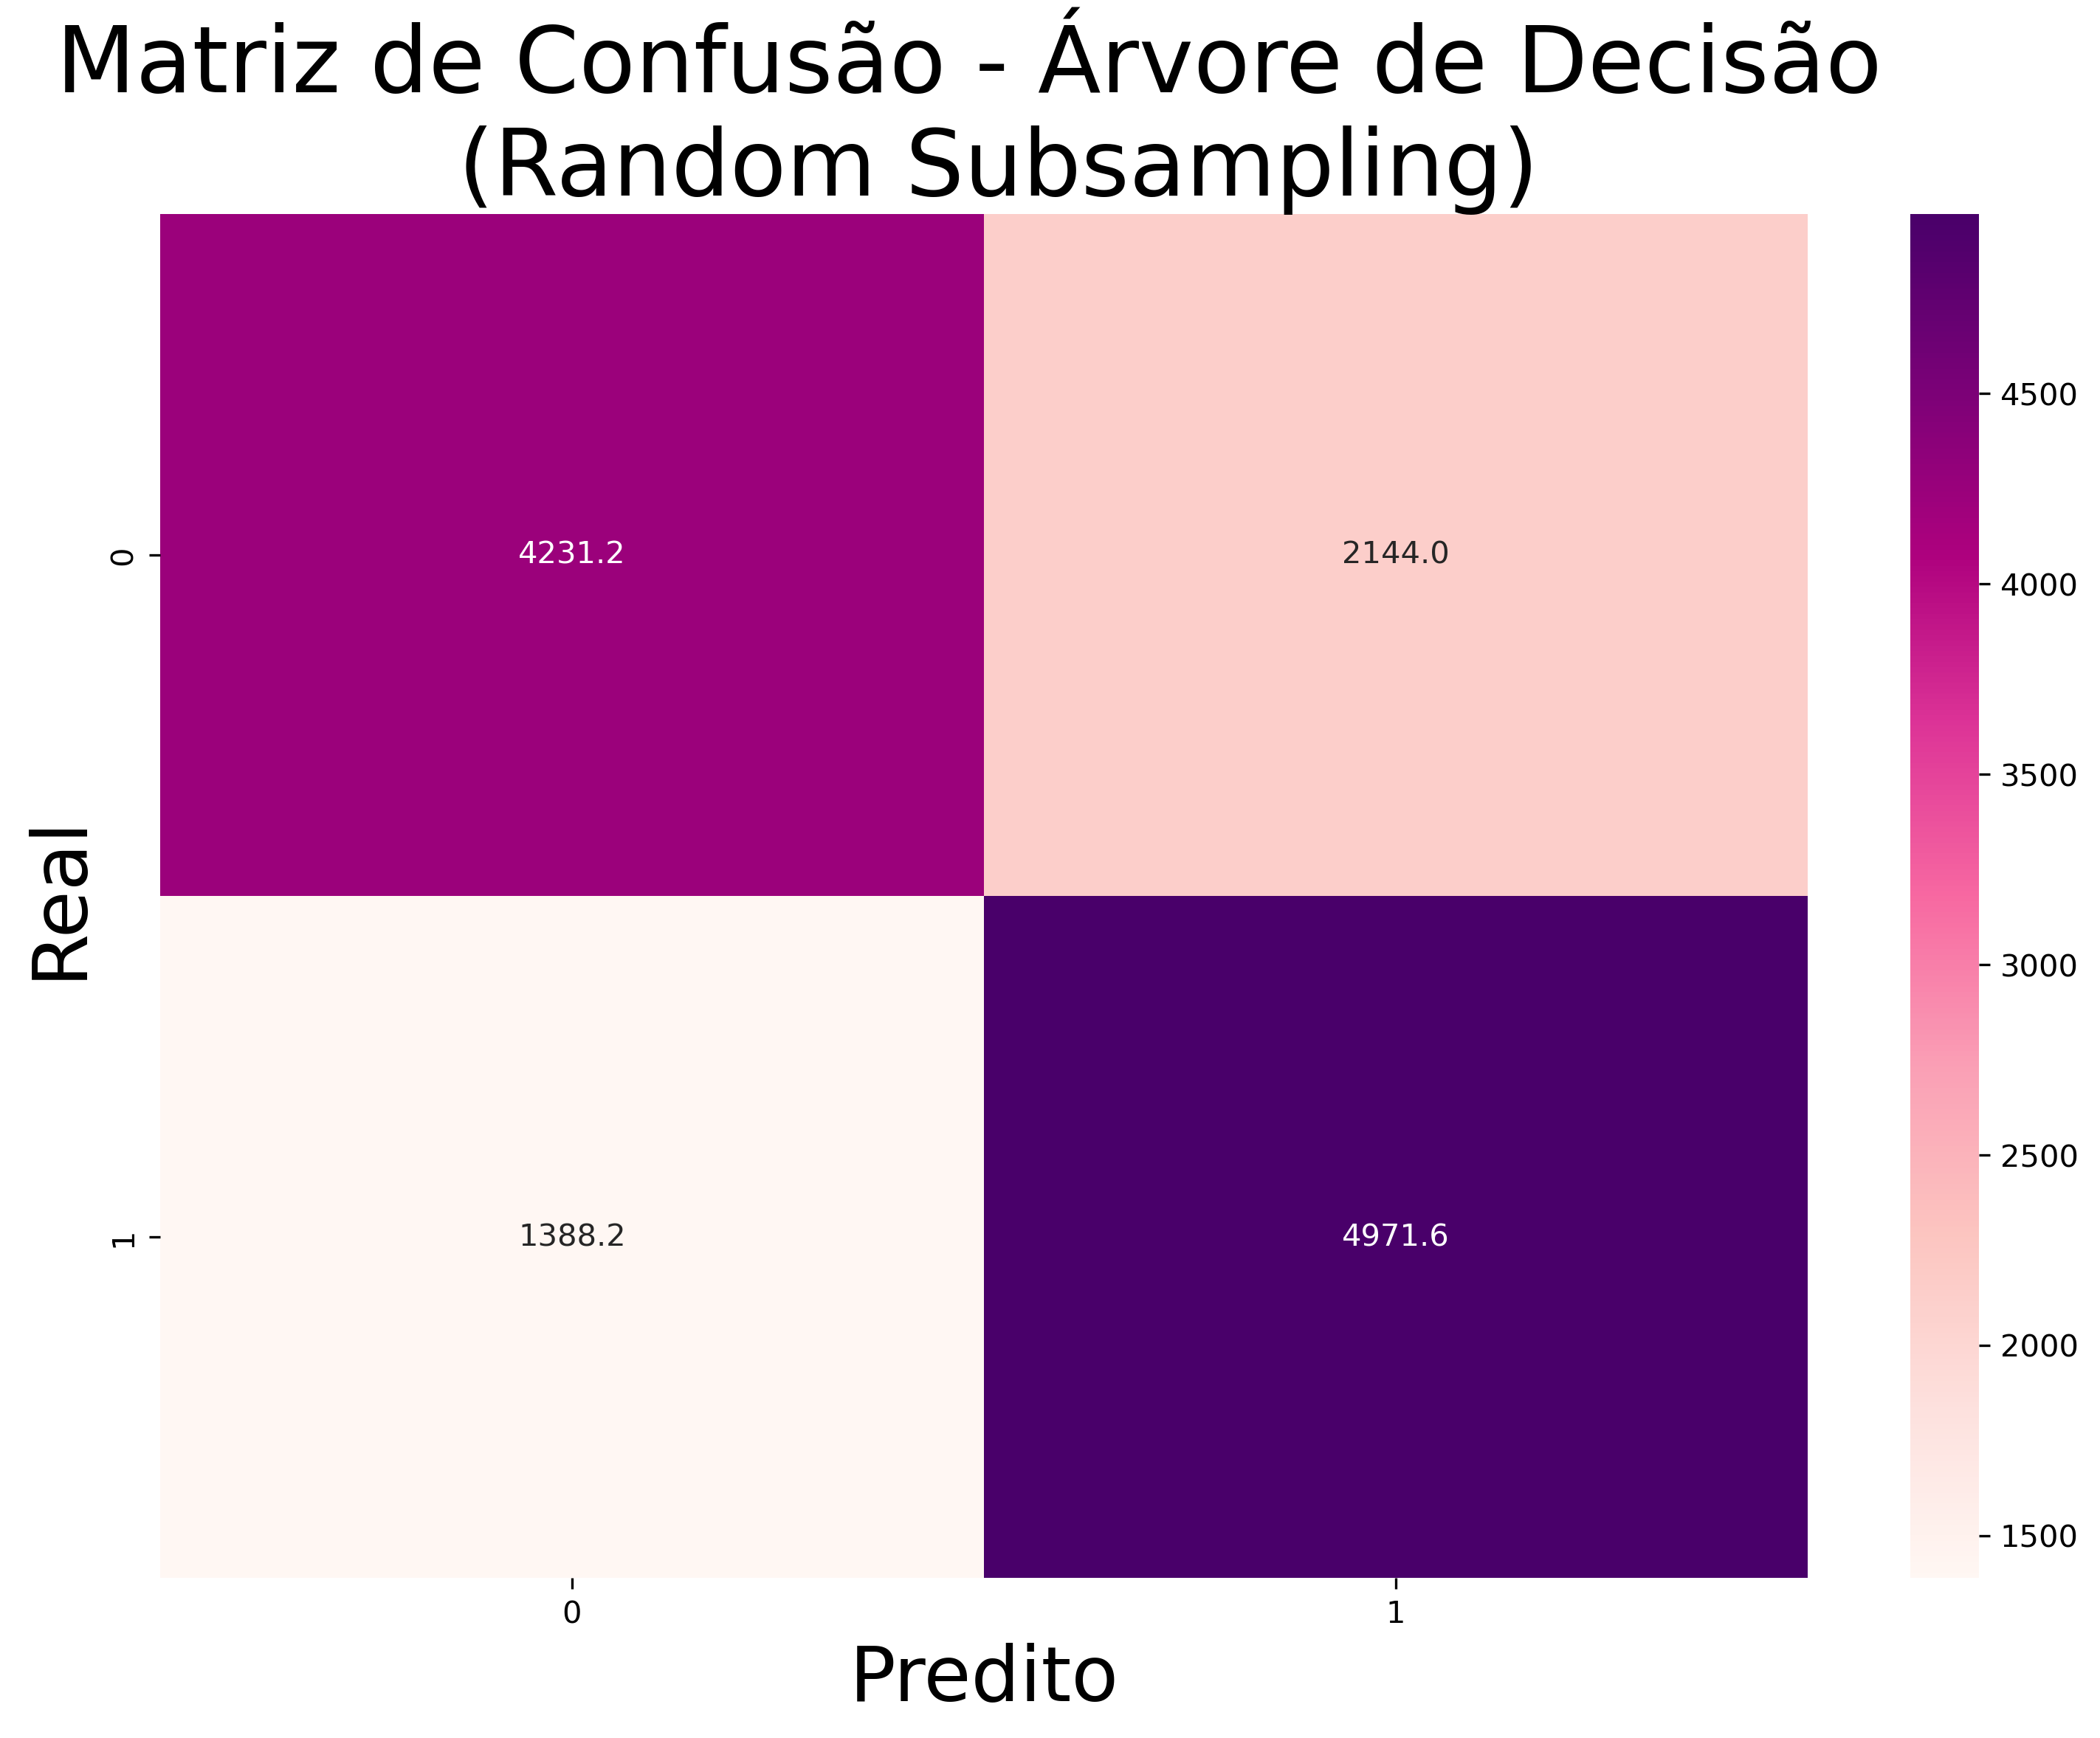

In [17]:
#matriz de confusão
media_matriz = np.mean(matrizes_confusao, axis=0)

plt.figure(figsize=(12, 8), dpi=300)
sns.heatmap(media_matriz, annot=True, fmt=".1f", cmap="RdPu")
plt.xlabel("Predito",fontsize=25)
plt.ylabel("Real",fontsize =25)
plt.title("Matriz de Confusão - Árvore de Decisão \n (Random Subsampling)", fontsize=30)
plt.savefig("decision_tree_matriz_confusao_random_subsampling.png", dpi=300)

### CURVA ROC

C:\Users\apisa\AppData\Local\Temp\ipykernel_1436\1190360176.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], "k--", lw=2, color='#a80dbd')


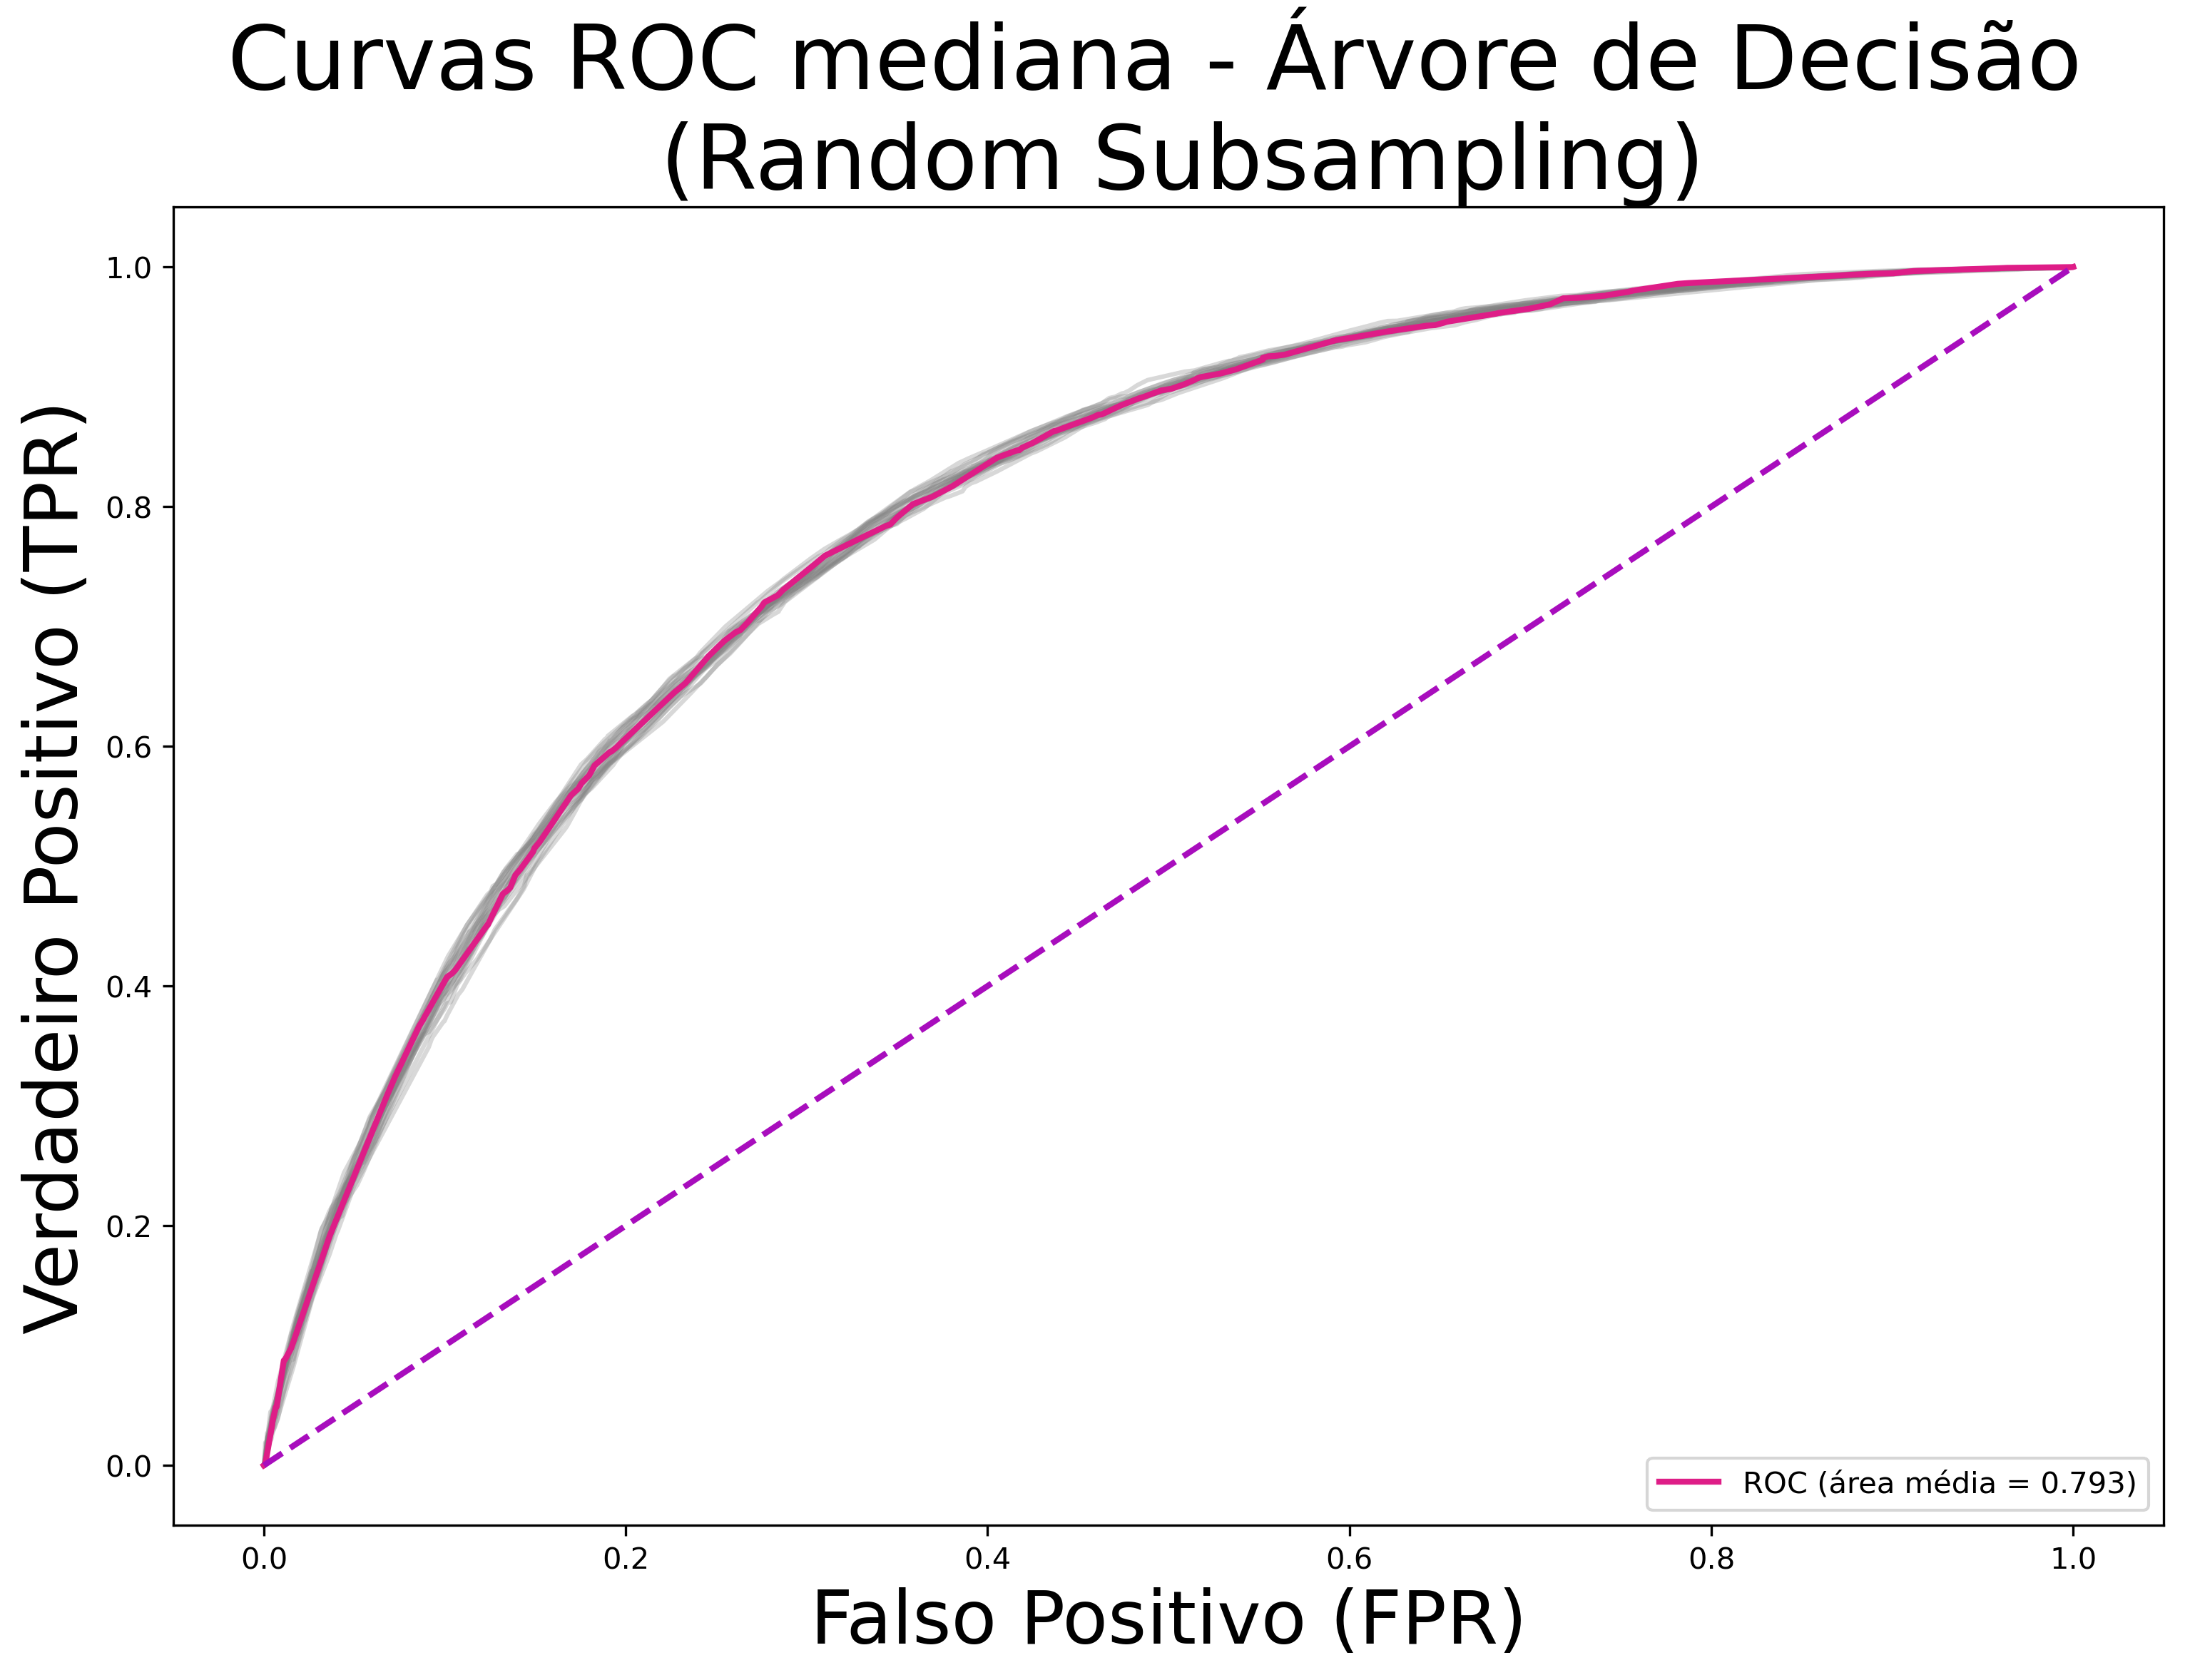

In [18]:
# Plotando
plt.figure(figsize=(12, 8),dpi=300)

# Curvas individuais
for i in range(n_rep):
    plt.plot(fpr_list[i], tpr_list[i], color="gray", alpha=0.3)

# Curva média aproximada
# AUC mediana
idx_mediana = np.argsort(auc_list)[len(auc_list)//2]
plt.plot(fpr_list[idx_mediana], tpr_list[idx_mediana],
         color='#de1d87', lw=2, label=f"ROC (área média = {np.mean(auc_list):.3f})")

# Linha aleatória
plt.plot([0, 1], [0, 1], "k--", lw=2, color='#a80dbd')

plt.xlabel("Falso Positivo (FPR)", fontsize=25)
plt.ylabel("Verdadeiro Positivo (TPR)", fontsize=25)
plt.title("Curvas ROC mediana - Árvore de Decisão \n (Random Subsampling)", fontsize=30)
plt.legend(loc="lower right")
plt.savefig("decision_tree_curva_roc_random_subsampling.png", dpi=300)